In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge, Lasso, ElasticNet

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score




/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("master_dataset_modelling.csv")
df_synthetic = pd.read_csv("synthetic_dataset.csv")


## FEATURE ENGINEERING

# Sudying the correlation among: Y vs lagged Y, Y vs lagged X variables

Only keeping the most correlated variables.


In [3]:
#Lagged correlation for Y_Cost_Per_Ton

Y = df['Y_Cost_Per_Ton']

max_lag = 12
results_y = []

for lag in range(1, max_lag + 1):
    Y_lag = Y.shift(lag)
    corr = Y.corr(Y_lag)

    results_y.append({
        'Variable': 'Y_Cost_Per_Ton',
        'Lag': lag,
        'Correlation': corr
    })

df_lagY_corr = pd.DataFrame(results_y)
df_lagY_corr = df_lagY_corr.sort_values(by='Correlation', ascending=False)

df_lagY_corr



,Variable,Lag,Correlation
0,Y_Cost_Per_Ton,1,0.410941
1,Y_Cost_Per_Ton,2,0.347296
2,Y_Cost_Per_Ton,3,0.315984
3,Y_Cost_Per_Ton,4,0.303506
11,Y_Cost_Per_Ton,12,0.220452
4,Y_Cost_Per_Ton,5,0.187725
5,Y_Cost_Per_Ton,6,0.160984
7,Y_Cost_Per_Ton,8,0.132874
6,Y_Cost_Per_Ton,7,0.131789
9,Y_Cost_Per_Ton,10,0.087931


In [4]:
#Lagged correlation for all X variables vs Y_Cost_Per_Ton

Y = df['Y_Cost_Per_Ton']

#select only X columns
X_cols = [col for col in df.columns if col.startswith("X")]

max_lag = 12
results = []

for col in X_cols:
    for lag in range(0, max_lag + 1):
        X_lag = df[col].shift(lag)
        corr = Y.corr(X_lag)

        results.append({
            'Variable': col,
            'Lag': lag,
            'Correlation': corr
        })

df_lagX_corr = pd.DataFrame(results)

# ordered by absolute correlation value
df_lagX_corr = df_lagX_corr.reindex(
    df_lagX_corr['Correlation'].abs().sort_values(ascending=False).index
)



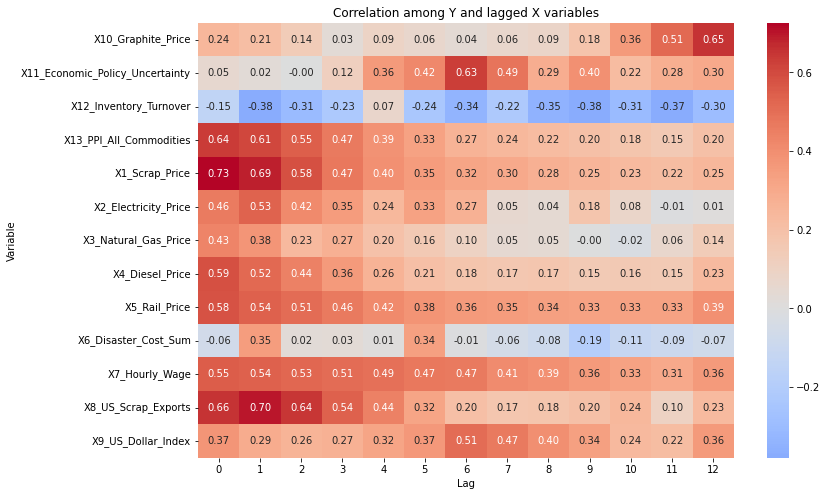

In [5]:
#heatmap of correlations

heatmap_df = df_lagX_corr.pivot(index='Variable', columns='Lag', values='Correlation')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation among Y and lagged X variables")
plt.show()


# Studying correlation: Y vs rolling X variables

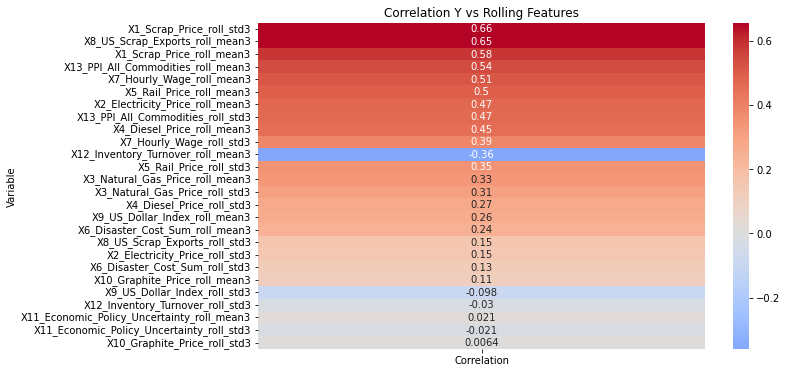

In [6]:
#Rolling statistics features and their correlation with Y_Cost_Per_Ton
window = 3  

vol_vars = [
    'X1_Scrap_Price',
    'X2_Electricity_Price',
    'X3_Natural_Gas_Price',
    'X4_Diesel_Price',
    'X5_Rail_Price',
    'X6_Disaster_Cost_Sum',
    'X7_Hourly_Wage',
    'X8_US_Scrap_Exports',
    'X9_US_Dollar_Index',
    'X10_Graphite_Price',
    'X11_Economic_Policy_Uncertainty',
    'X12_Inventory_Turnover',
    "X13_PPI_All_Commodities"
]

for col in vol_vars:
    df[f'{col}_roll_mean{window}'] = df[col].shift(1).rolling(window).mean()
    df[f'{col}_roll_std{window}'] = df[col].shift(1).rolling(window).std()

rolling_cols = [c for c in df.columns if '_roll_' in c]

results_rolling = []

Y = df['Y_Cost_Per_Ton']

for col in rolling_cols:
    corr = Y.corr(df[col])
    results_rolling.append({
        'Variable': col,
        'Correlation': corr
    })

df_rolling_corr = pd.DataFrame(results_rolling)
df_rolling_corr = df_rolling_corr.sort_values(by='Correlation', key=lambda x: x.abs(), ascending=False)

plt.figure(figsize=(10,6))
sns.heatmap(df_rolling_corr.set_index('Variable'), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Y vs Rolling Features')
plt.show()

## LINEAR REGRESSION WITH RIDGE, LASSO, ELASTICNET

Main function to run Ridge, Lasso, ElasticNet

In [7]:
def run_models_cv(df, n_splits, selected_features):

    df = df.copy()
    df["QuarterEnd"] = pd.to_datetime(df["QuarterEnd"])

    X = df[selected_features]
    y = df['Y_Cost_Per_Ton']
    dates = df["QuarterEnd"].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits)

    models = {
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=10.0),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
    }

    predictions = {}
    r2_scores = {}

    for name, model_reg in models.items():

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', model_reg)
        ])

        y_pred_all = pd.Series(index=y.index, dtype=float)
        fold_r2_scores = []

        print(f"--- {name} ---")
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_all.iloc[test_idx] = y_pred

            # R² per fold
            r2_fold = r2_score(y_test, y_pred)
            fold_r2_scores.append(r2_fold)

            # Dates for the test set
            test_dates = dates.iloc[test_idx].dt.strftime('%Y-%m-%d').tolist()

            print(f"{test_dates[0]} -> {test_dates[-1]} : R² = {r2_fold:.4f}")

        r2_scores[name] = fold_r2_scores
        print(f"Mean R² {name}: {np.mean(fold_r2_scores):.4f}\n")
        predictions[name] = y_pred_all

    # plot real vs predicted for all models
    plt.figure(figsize=(14, 6))
    plt.plot(dates, y, label="Real", color="black", linewidth=2)
    for name, pred in predictions.items():
        plt.plot(dates, pred, linestyle="--", linewidth=1.8, label=name)
    plt.title("Real vs Predicted – All Models")
    plt.xlabel("Date")
    plt.ylabel("Cost per Ton")
    plt.grid(True)
    plt.legend()
    plt.show()

    return {
        "dates": dates,
        "y_real": y,
        "predictions": predictions,
        "r2_scores": r2_scores
    }


In [8]:
def plot_period(results, start_date, end_date):

    dates = results["dates"]
    y_real = results["y_real"]
    preds = results["predictions"]

    start_date = pd.to_datetime(start_date)
    end_date   = pd.to_datetime(end_date)

    mask = (dates >= start_date) & (dates <= end_date)

    plt.figure(figsize=(14, 5))

    # Real
    plt.plot(dates[mask], y_real[mask], color="black", linewidth=2, label="Real")

    # model predictions
    for name, pred in preds.items():
        plt.plot(dates[mask], pred[mask], linestyle="--", linewidth=1.8, label=name)

    plt.title(f"Model comparison from {start_date.date()} to {end_date.date()}")
    plt.xlabel("Date")
    plt.ylabel("Cost per Ton")
    plt.grid(True)
    plt.legend()
    plt.show()


# Here with the synthetic dataset

I don't used lagged features because synthetic data created with gaussian copula 'break' with temporal data

In [9]:
nonlagged_features = [
    'X1_Scrap_Price', 'X2_Electricity_Price', 'X4_Diesel_Price',
    'X5_Rail_Price', 'X7_Hourly_Wage', 'X8_US_Scrap_Exports',
    'X12_Inventory_Turnover', 'X13_PPI_All_Commodities'
]

--- Ridge ---
1978-06-30 -> 1987-09-30 : R² = 0.5001
1987-12-31 -> 1997-03-31 : R² = 0.1661
1997-06-30 -> 2006-09-30 : R² = 0.5142
2006-12-31 -> 2016-03-31 : R² = 0.5973
2016-06-30 -> 2025-09-30 : R² = 0.5250
Mean R² Ridge: 0.4605

--- Lasso ---
1978-06-30 -> 1987-09-30 : R² = 0.4842
1987-12-31 -> 1997-03-31 : R² = 0.2156
1997-06-30 -> 2006-09-30 : R² = 0.4871
2006-12-31 -> 2016-03-31 : R² = 0.5857
2016-06-30 -> 2025-09-30 : R² = 0.5358
Mean R² Lasso: 0.4617

--- ElasticNet ---
1978-06-30 -> 1987-09-30 : R² = 0.4903
1987-12-31 -> 1997-03-31 : R² = 0.1738
1997-06-30 -> 2006-09-30 : R² = 0.5091
2006-12-31 -> 2016-03-31 : R² = 0.5870
2016-06-30 -> 2025-09-30 : R² = 0.5306
Mean R² ElasticNet: 0.4582



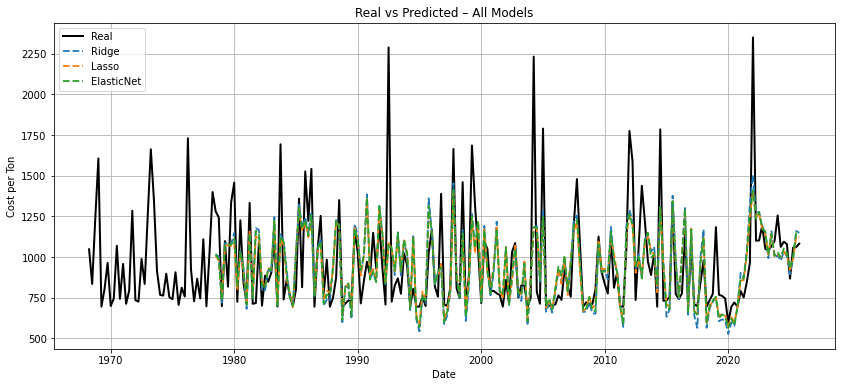

In [10]:
run_synthetic_dataset = run_models_cv(df_synthetic, n_splits=5, selected_features=nonlagged_features)

## REGRESSION WITH MASTER DATASET

In [11]:
df = pd.read_csv("master_dataset_modelling.csv")


In [12]:
# top correlated features and their lags
top_features = [
    ('X8_US_Scrap_Exports', [1,2]),
    ('X4_Diesel_Price', [1]),
    ('X5_Rail_Price', [1]),
    ('Y_Cost_Per_Ton', [1,2])

]

# create lagged features in the dataframe
for col, lags in top_features:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)


In [13]:
df['Y_roll3'] = df['Y_Cost_Per_Ton'].shift(1).rolling(3).mean()

In [14]:
# Removes rows with NaN values created by lagging/rolling
df = df.dropna().reset_index(drop=True)

I use only a small subset of most correlated features (with Y) to avoid more overfitting

In [15]:
top_lagged_features_small_dataset = [
    'X1_Scrap_Price',       
    'X8_US_Scrap_Exports_lag1',  
    'X13_PPI_All_Commodities',
    "Y_Cost_Per_Ton_lag1"

]


In [16]:
nonlagged_features_small_dataset = [
    'X1_Scrap_Price', 'X8_US_Scrap_Exports', 'X4_Diesel_Price', 
    'X5_Rail_Price', 'X13_PPI_All_Commodities'
]

--- Ridge ---
2018-06-30 -> 2019-09-30 : R² = -1.0210
2019-12-31 -> 2021-03-31 : R² = -1.4467
2021-06-30 -> 2022-09-30 : R² = -1.0831
2022-12-31 -> 2024-03-31 : R² = -4.3243
2024-06-30 -> 2025-09-30 : R² = -0.0034
Mean R² Ridge: -1.5757

--- Lasso ---
2018-06-30 -> 2019-09-30 : R² = -2.1175
2019-12-31 -> 2021-03-31 : R² = -3.2577
2021-06-30 -> 2022-09-30 : R² = -0.2320
2022-12-31 -> 2024-03-31 : R² = -1.7869
2024-06-30 -> 2025-09-30 : R² = 0.1800
Mean R² Lasso: -1.4428

--- ElasticNet ---
2018-06-30 -> 2019-09-30 : R² = -2.0329
2019-12-31 -> 2021-03-31 : R² = -1.2528
2021-06-30 -> 2022-09-30 : R² = -0.9889
2022-12-31 -> 2024-03-31 : R² = -2.7446
2024-06-30 -> 2025-09-30 : R² = 0.0929
Mean R² ElasticNet: -1.3853



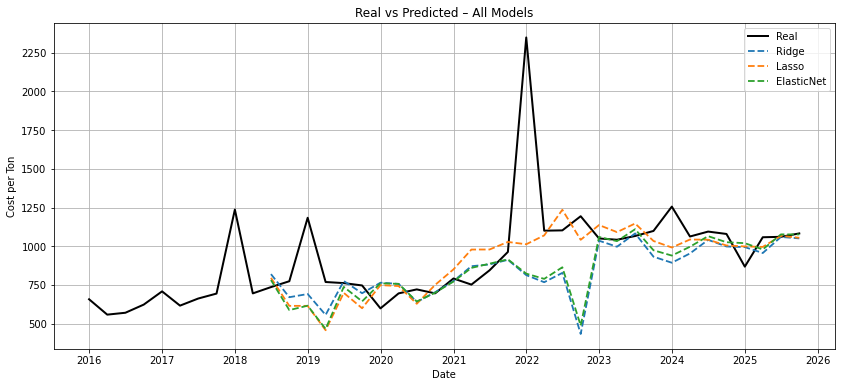

In [17]:
results_nonlagged_features = run_models_cv(df, n_splits=5, selected_features=nonlagged_features_small_dataset)

# Run with lagged features

R2 decreases a bit, but the model better predicts the most volatile period (Ukraine War)

--- Ridge ---
2018-06-30 -> 2019-09-30 : R² = -0.7391
2019-12-31 -> 2021-03-31 : R² = -3.2431
2021-06-30 -> 2022-09-30 : R² = -0.0423
2022-12-31 -> 2024-03-31 : R² = -3.3414
2024-06-30 -> 2025-09-30 : R² = -0.2118
Mean R² Ridge: -1.5155

--- Lasso ---
2018-06-30 -> 2019-09-30 : R² = -1.2804
2019-12-31 -> 2021-03-31 : R² = -2.8930
2021-06-30 -> 2022-09-30 : R² = -0.0606
2022-12-31 -> 2024-03-31 : R² = -1.1401
2024-06-30 -> 2025-09-30 : R² = -0.3948
Mean R² Lasso: -1.1538

--- ElasticNet ---
2018-06-30 -> 2019-09-30 : R² = -1.1275
2019-12-31 -> 2021-03-31 : R² = -3.2945
2021-06-30 -> 2022-09-30 : R² = -0.0379
2022-12-31 -> 2024-03-31 : R² = -2.1198
2024-06-30 -> 2025-09-30 : R² = -0.1683
Mean R² ElasticNet: -1.3496



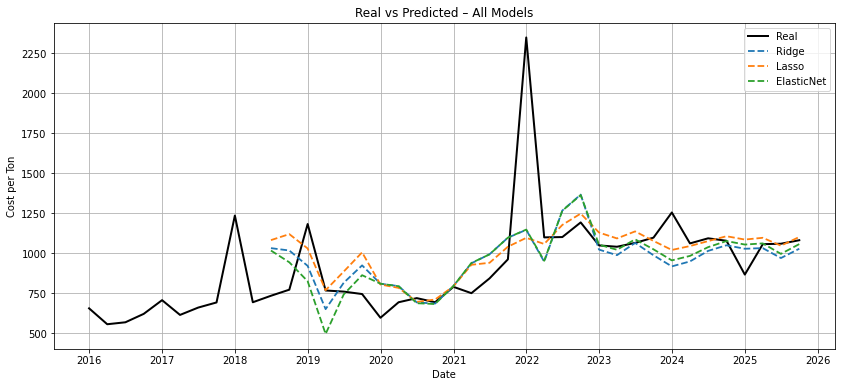

In [18]:
results_lagged_features = run_models_cv(df, n_splits=5, selected_features = top_lagged_features_small_dataset)

Another run with a slightly different subset of features: Y_roll3 instead of Y_Cost_Per_Ton_lag1.
We loose a bit in mean R2, but the model is able to have a positive R2 in 2021-06-30 -> 2022-09-30.
It's a very volatile period because it's the starting uf Ukraine war

In [19]:
top_lagged_features_small_dataset_2 = [
    'X1_Scrap_Price',       
    'X8_US_Scrap_Exports_lag1',  
    'X13_PPI_All_Commodities',
    "Y_roll3"
]

--- Ridge ---
2018-06-30 -> 2019-09-30 : R² = -0.8472
2019-12-31 -> 2021-03-31 : R² = -10.8385
2021-06-30 -> 2022-09-30 : R² = 0.2544
2022-12-31 -> 2024-03-31 : R² = -1.0033
2024-06-30 -> 2025-09-30 : R² = -0.9127
Mean R² Ridge: -2.6695

--- Lasso ---
2018-06-30 -> 2019-09-30 : R² = 0.2066
2019-12-31 -> 2021-03-31 : R² = -8.8456
2021-06-30 -> 2022-09-30 : R² = 0.1186
2022-12-31 -> 2024-03-31 : R² = -0.9805
2024-06-30 -> 2025-09-30 : R² = -0.5892
Mean R² Lasso: -2.0180

--- ElasticNet ---
2018-06-30 -> 2019-09-30 : R² = -3.7350
2019-12-31 -> 2021-03-31 : R² = -11.4982
2021-06-30 -> 2022-09-30 : R² = 0.2523
2022-12-31 -> 2024-03-31 : R² = -0.9436
2024-06-30 -> 2025-09-30 : R² = -0.9467
Mean R² ElasticNet: -3.3742



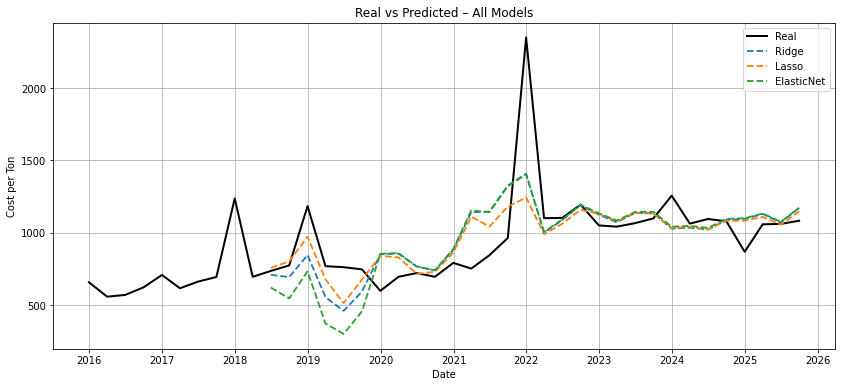

In [20]:
results_lagged_features_2 = run_models_cv(df, n_splits=5, selected_features = top_lagged_features_small_dataset_2)

## Zoom on critical periods: Ukraine war

With non lagged features

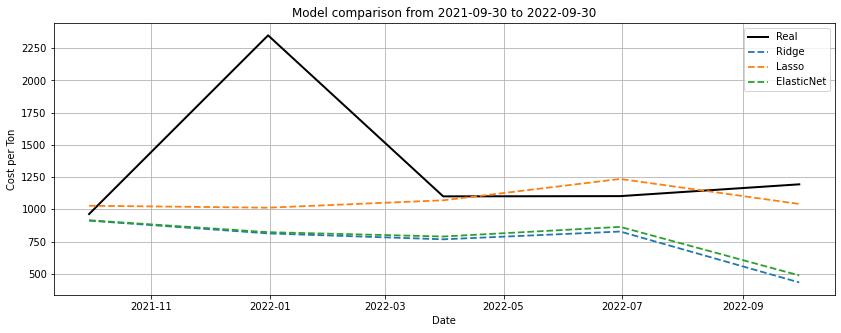

In [21]:
plot_period(results_nonlagged_features, "2021-09-30", "2022-09-30")

With lagged features

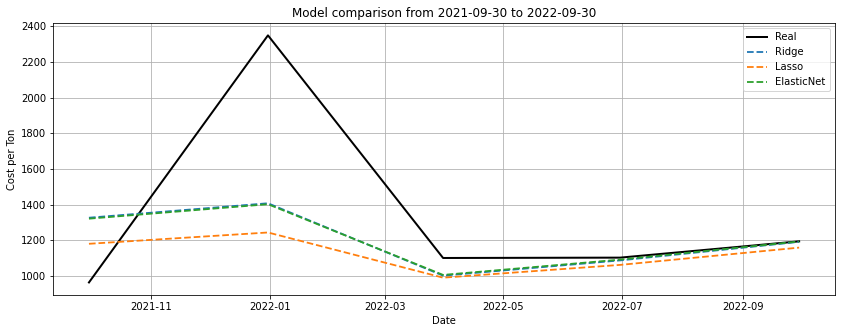

In [22]:
plot_period(results_lagged_features_2, "2021-09-30", "2022-09-30")